<a href="https://colab.research.google.com/github/Olivier812/Computational-methods-for-multi-modal-data-analysis-assignment/blob/main/Assignment_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IIDS67692 Computational Techniques for Multi-modal Data
##Assignment Part-B: Multimodal Fusion and LoRA Adaptation for Heath Decision Support



In [ ]:
!nvidia-smi

###Installing required python packages

In [5]:
!pip install -q datasets evaluate bert_score rouge_score torch torchvision transformers peft gdown --upgrade pip --upgrade torchao

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.4 MB/s eta 0:00:00
   ━━━━

#Dataset

Huggingface Link: https://huggingface.co/datasets/flaviagiammarino/path-vqa

The PathVQA Dataset is available on Hugging Face and contains 19,654 training, 6,259 validation, and 6,719 test question-answer pairs across approximately 5,004 pathology images.

The PathVQA Dataset is a large-scale medical visual question answering benchmark designed for pathology image understanding. It contains more than 32,000 question-answer pairs associated with pathology images collected from publicly available medical sources. The dataset supports multimodal AI research by combining visual pathology information with natural language reasoning tasks, enabling models to answer clinically relevant questions about tissue appearance, disease characteristics, and diagnostic findings. PathVQA has become a widely used benchmark for evaluating medical VQA systems and multimodal large language models in digital pathology research.

[1] He, Xuehai, et al. "Towards visual question answering on pathology images." Proceedings of the 59th Annual Meeting of the Association for Computational Linguistics and the 11th International Joint Conference on Natural Language Processing (Volume 2: Short Papers). 2021.

[2] He, Xuehai, et al. "Pathvqa: 30000+ questions for medical visual question answering." arXiv preprint arXiv:2003.10286 (2020).

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/validation-00000-of-00003-90a5518d2(…):   0%|          | 0.00/41.3M [00:00<?, ?B/s]

data/validation-00001-of-00003-cbfe947a3(…):   0%|          | 0.00/45.7M [00:00<?, ?B/s]

data/validation-00002-of-00003-9ec816895(…):   0%|          | 0.00/64.7M [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

KeyboardInterrupt: 

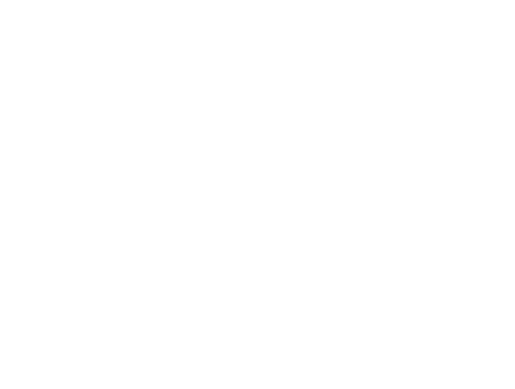

In [6]:
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
plt.axis('off')

pathvqa_valid = load_dataset("parquet", data_files={"validation": "hf://datasets/flaviagiammarino/path-vqa/data/validation-*.parquet"}, split="validation")
print('samplesize:', len(pathvqa_valid))
idx=3
print(pathvqa_valid[idx].keys())
print('image reso;ution:', np.array(pathvqa_valid[idx]['image']).shape)
plt.imshow(pathvqa_valid[idx]['image'])
plt.title(f'Q: {pathvqa_valid[idx]['question']}\nA: {pathvqa_valid[idx]['answer']}', fontsize=12)


#Prepare Dataloader

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader


class PathVQADataset(Dataset):
    def __init__(self, hf_dataset):
        """
        hf_dataset: HuggingFace dataset (already loaded split)
        """

        self.dataset = hf_dataset

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        # --- Image ---
        # HF dataset already provides PIL image
        raw_image = sample["image"].convert('RGB')
        img = self.transform(raw_image)

        # --- Question & Answer ---
        question = sample["question"]
        answer = sample["answer"]

        return img, question, answer

subset = pathvqa_valid.shuffle(seed=42).select(range(3000))
split_dataset = subset.train_test_split(test_size=0.2, seed=42)

# split_dataset = pathvqa_valid.train_test_split(test_size=0.2, seed=42)

train_data = split_dataset["train"]
val_data   = split_dataset["test"]
print(f'split: train = {len(train_data)} and test={len(val_data)}')

train_dataset = PathVQADataset(train_data)
val_dataset   = PathVQADataset(val_data)
print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)


img, question, answer = train_dataset[1]
print('image resolution:', img.size())
plt.axis('OFF')
plt.imshow(img.permute(1,2,0))
plt.title(f'Q: {question}\nA: {answer}', fontsize=12)

#Model Architecture

Paper: https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

GPT-2 uses a decoder-only transformer architecture with multiple model sizes; the commonly used GPT-2 Base model contains 12 transformer blocks (layers), a context window of 1024 tokens, a hidden embedding size of 768, and about 117 million parameters, while larger variants scale up to 48 transformer blocks and 1.5 billion parameters.

[1] Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. OpenAI blog, 1(8), 9.

###Cross-Attention Fusion

In [ ]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

####Cross-Attention Fusion###########
class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8, dropout=0.1):
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        text_embeds:  [B, T, 768]
        image_embeds: [B, N, 768]
        text attends to image
        """

        attended_text, attn_weights = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )

        x = self.norm1(text_embeds + attended_text)
        x = self.norm2(x + self.ffn(x))

        return x

###Gated Cross-Attention Fusion

In [ ]:
#Write your code for Gated-Cross Attention Fusion

###MedVQA model (Mulitmodal GPT2)

In [ ]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        # self.gpt.print_trainable_parameters()  # Verify trainable LoRA parameters
        self.fusion = CrossAttentionFusion(
            hidden_dim=768,
            num_heads=4
        )

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        # [B, 197, 768]

        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)
        # [B, T, 768]

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_embeds,
            text_att_mask=qa_att_mask
        )
        # [B, T, 768]

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )
        return gpt_output.logits

#Model Training

In [ ]:
#Training Script for Multimodal GPT2 with LoRA

#Inference: few samples (prediction visualisations)

In [ ]:
#run inference to collect the prediction visualisations

#Inference: (Evaluation Metrics)

In [ ]:
#run inference to collect the evaluation metrics (BLEU, ROUGE-L, and METEOR)